In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro



In [111]:
data = pd.read_csv("C:/Users/Chet/Documents/practice_data.csv")


In [113]:
data.head()

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes


## Check Distributions

In [116]:
numeric_columns = [
    'Days Present',
    'Task Completion Rates',
    'Interpersonal Skills Rating',
    'Decision-Making Skills Rating',
    'Sales Revenue Generated']


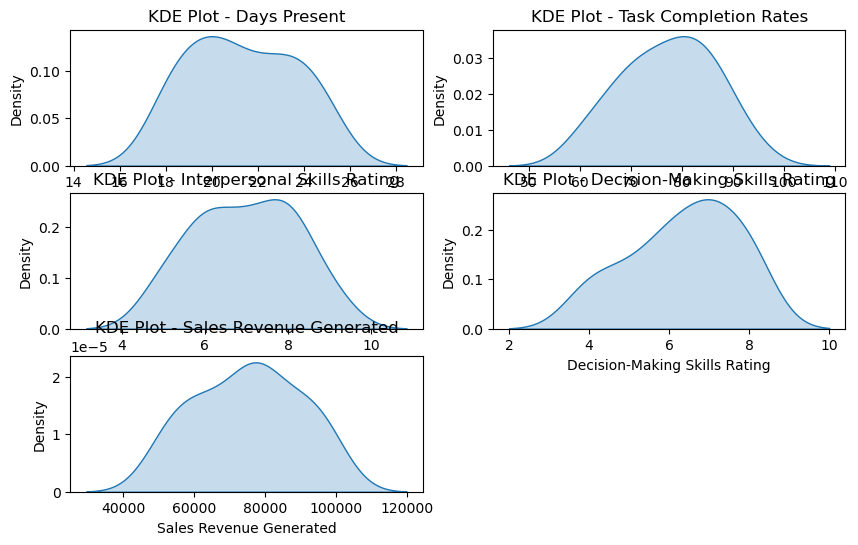

In [118]:
num_plots = len(numeric_columns)
num_col = 2
num_row = int(np.ceil(num_plots / num_col))


fig, axes = plt.subplots(num_row, num_col, figsize=(10, 6))
axes = axes.flatten()  # Flatten to easily index axes


for index, column in enumerate(numeric_columns):
    sns.kdeplot(data[column], ax=axes[index], fill=True)
    axes[index].set_title(f'KDE Plot - {column}')


for i in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[i])

## Normality

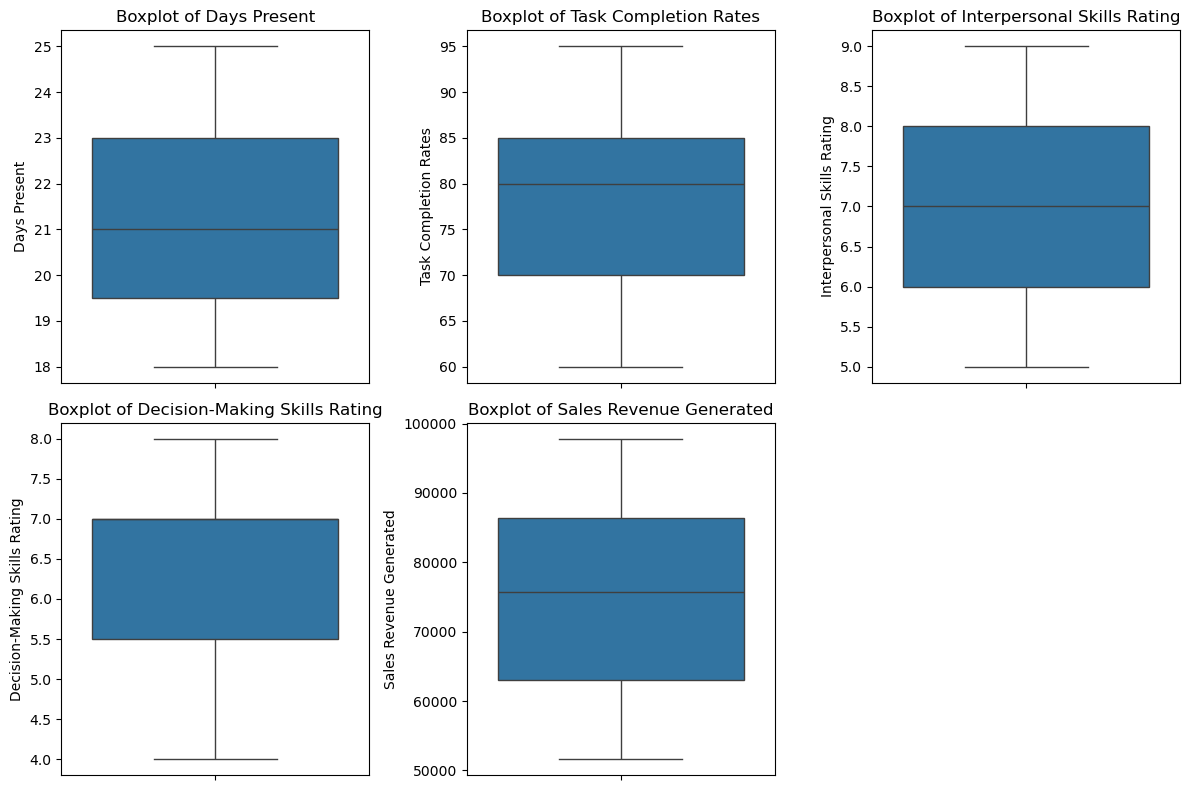

Shapiro-Wilk Test P-values:
{'Days Present': 0.044, 'Task Completion Rates': 0.321, 'Interpersonal Skills Rating': 0.015, 'Decision-Making Skills Rating': 0.004, 'Sales Revenue Generated': 0.12}


In [120]:

numeric_columns = [
    'Days Present', 'Task Completion Rates', 'Interpersonal Skills Rating',
    'Decision-Making Skills Rating', 'Sales Revenue Generated']


plt.figure(figsize=(12, 8))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

shapiro_results = {}

for column in numeric_columns:
    stat, p_value = shapiro(data[column])
    shapiro_results[column] = round(p_value, 3)

print("Shapiro-Wilk Test P-values:")
print(shapiro_results)

## Square Root

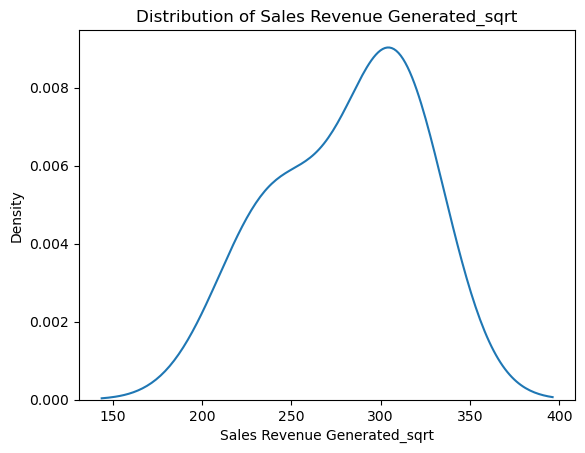

P-value from Shapiro-Wilk test: 0.1466331048362367


(0.8330597930391933, 0.1466331048362367)

In [123]:
def sqrt_transformation(data, column_name):
    

    data[f'{column_name}_sqrt'] = np.sqrt(data[column_name])
    

    stat, p_value = shapiro(data[f'{column_name}_sqrt'])
    
    sns.kdeplot(data[f'{column_name}_sqrt'])
    plt.title(f'Distribution of {column_name}_sqrt')
    plt.show()
    

    print(f'P-value from Shapiro-Wilk test: {p_value}')
    
    
    return stat, p_value

sqrt_transformation(df, 'Sales Revenue Generated')


## Log Transformation

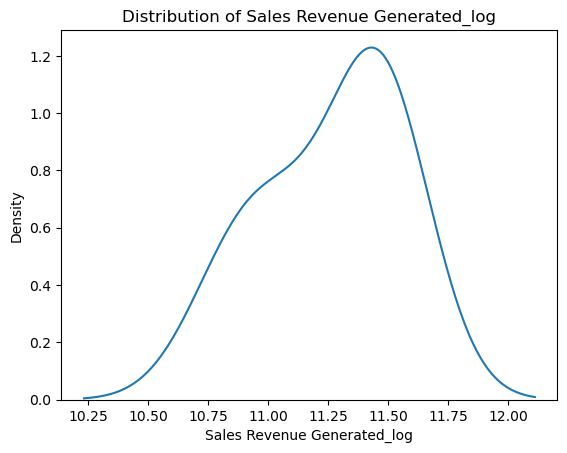

P-value from Shapiro-Wilk test: 0.13755240027213939


(0.8293439844354911, 0.13755240027213939)

In [127]:
def log_transformation(data, column_name):
   

    data[f'{column_name}_log'] = np.log(data[column_name])
    
    stat, p_value = shapiro(data[f'{column_name}_log'])
    
    sns.kdeplot(data[f'{column_name}_log'])
    plt.title(f'Distribution of {column_name}_log')
    plt.show()
    
    print(f'P-value from Shapiro-Wilk test: {p_value}')
    
    return stat, p_value


log_transformation(df, 'Sales Revenue Generated')


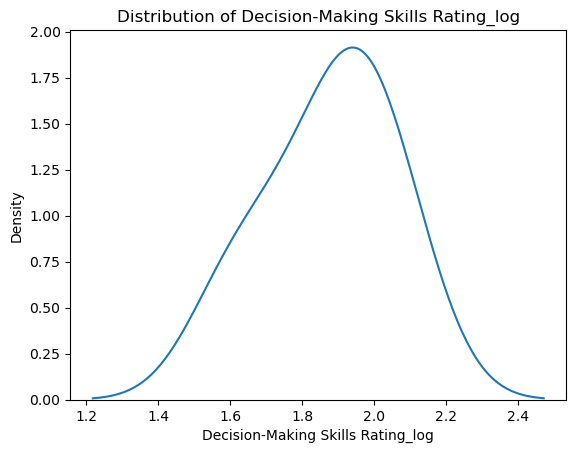

P-value from Shapiro-Wilk test: 0.7025820756393323


(0.9451561287756515, 0.7025820756393323)

In [129]:
log_transformation(df, 'Decision-Making Skills Rating')